# Melting Point 예측 — v9_optuna (Stacking Ensemble)

**차별점**: v5 ResidualMLP + XGBoost + LightGBM → Ridge meta-learner

**공통**: 데이터, split, CV, 피처, 모델 아키텍처, 학습, 평가 모두 v5와 동일

**목표**: Test R² 0.7536 (v5) → 0.78~0.82

In [91]:
# Mac OS 한글 폰트 깨짐 방지
import matplotlib.pyplot as plt
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn optuna rdkit torch xgboost lightgbm -q

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import Ridge
import platform, subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, shutil

# 1. 꼬여있는 Matplotlib 폰트 캐시 강제 초기화 (네모 에러의 주원인)
matplotlib_cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(matplotlib_cache_dir):
    shutil.rmtree(matplotlib_cache_dir)
plt.style.use('default')

# 2. OS에 맞춘 확실한 폰트 세팅 (맥 환경 Apple SD Gothic Neo 적용)
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams["font.family"] = "NanumGothic"
elif platform.system() == 'Darwin':
    # Mac OS용 최신 표준 한글 폰트 적용
    plt.rcParams["font.family"] = "Apple SD Gothic Neo"
else:
    # Windows용 폰트 설정
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
import torch
import numpy as np
import time
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T0 = time.time()

print("라이브러리 로드 및 Mac 폰트 셋업 완전 해결 완료")


라이브러리 로드 및 Mac 폰트 셋업 완전 해결 완료


## 1. 데이터 로드

In [93]:
df = pd.read_csv("https://raw.githubusercontent.com/sunghee-sketch/middle-test/main/data/Melting_point_2.csv")
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["MP"] >= 0].reset_index(drop=True)
df["MP_log"] = np.log1p(df["MP"])
print(f"데이터 크기: {df.shape}")
print(f"MP 범위: {df['MP'].min():.1f} ~ {df['MP'].max():.1f} K")
df.head()

데이터 크기: (2117, 3)
MP 범위: 13.9 ~ 1870.0 K


,SMILES,MP,MP_log
0,CCN(O)CC,247.650,5.516046
1,c1(C(C)=C)ccccc1,249.950,5.525254
2,C/C=C/CCCC,164.000,5.105945
3,c1(CC)cc(CC)cc(CC)c1,206.735,5.336263
4,COC(C)(C)C(=O)OC,229.600,5.440685


## 2. 피처 추출 (Morgan + MACCS + RDKit) + Murcko Scaffold
v5와 동일 — 2431차원 + scaffold.

In [94]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
desc_list  = [(n, f) for n, f in Descriptors.descList if not n.startswith("Ipc")]

def smiles_to_features_and_scaffold(smiles_list):
    records, scaffolds, valid_idx = [], [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        morgan = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
        descs  = []
        for _, func in desc_list:
            try:
                v = func(mol)
                descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
            except Exception:
                descs.append(0.0)
        records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
        # Murcko scaffold (빈 scaffold면 SMILES 자체 사용)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds.append(scaf if scaf else smi)
        except Exception:
            scaffolds.append(smi)
        valid_idx.append(i)
    X = np.array(records, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, scaffolds, valid_idx

print("피처 + scaffold 추출 중...")
t = time.time()
X_all, scaffolds_all, valid_idx = smiles_to_features_and_scaffold(df["SMILES"].tolist())
y_all     = df["MP"].values[valid_idx]
y_all_log = df["MP_log"].values[valid_idx]
scaf_arr  = np.array(scaffolds_all)
n_unique_scaf = len(set(scaffolds_all))
print(f"유효 샘플: {len(valid_idx)} / {len(df)}  |  피처 차원: {X_all.shape[1]}  |  소요: {time.time()-t:.1f}s")
print(f"Unique scaffold 수: {n_unique_scaf} (전체 분자의 {n_unique_scaf/len(valid_idx):.1%})")

피처 + scaffold 추출 중...
유효 샘플: 2117 / 2117  |  피처 차원: 2431  |  소요: 7.8s
Unique scaffold 수: 1527 (전체 분자의 72.1%)


## 3. Step A — VarianceThreshold

In [95]:
vt = VarianceThreshold(threshold=0.01)
X_all_vt = vt.fit_transform(X_all).astype(np.float32)
print(f"VarianceThreshold 전: {X_all.shape[1]} → 후: {X_all_vt.shape[1]} (제거: {X_all.shape[1] - X_all_vt.shape[1]})")

VarianceThreshold 전: 2431 → 후: 504 (제거: 1927)


## 4. Train/Test 분할 + 스케일링

In [96]:
mp_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")
indices = np.arange(len(X_all_vt))
tr_i, te_i = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=mp_bins
)
X_train, X_test = X_all_vt[tr_i], X_all_vt[te_i]
y_train, y_test = y_all[tr_i], y_all[te_i]
y_tr_log, y_te_log = y_all_log[tr_i].astype(np.float32), y_all_log[te_i].astype(np.float32)
scaf_train = scaf_arr[tr_i]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)
X_train_sc = np.clip(X_train_sc, -10.0, 10.0).astype(np.float32)
X_test_sc  = np.clip(X_test_sc,  -10.0, 10.0).astype(np.float32)

high_thr = np.percentile(y_train, 90)
sw_train = np.where(y_train >= high_thr, 3.0, 1.0).astype(np.float32)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")
print(f"Train 분자의 unique scaffold: {len(set(scaf_train))}")

Train: (1693, 504)  |  Test: (424, 504)
Train 분자의 unique scaffold: 1236


## 5. MI top-K (ANN 최종 모델용)

In [97]:
TOP_K = 300
print(f"전체 train MI 계산 중...")
t = time.time()
mi_full = mutual_info_regression(X_train_sc, y_tr_log, random_state=RANDOM_STATE, n_neighbors=3)
top_idx_full = np.argsort(mi_full)[::-1][:TOP_K]
X_train_sel_full = X_train_sc[:, top_idx_full]
X_test_sel_full  = X_test_sc[:, top_idx_full]
print(f"MI top-{TOP_K} (full-train) 완료 — {time.time()-t:.1f}s")
print(f"MI 상위 5 평균: {mi_full[top_idx_full[:5]].mean():.4f}  |  하위 5 평균: {mi_full[top_idx_full[-5:]].mean():.4f}")

전체 train MI 계산 중...
MI top-300 (full-train) 완료 — 1.8s
MI 상위 5 평균: 0.2790  |  하위 5 평균: 0.1216


## 6. 모델 정의 — ResidualMLP + Mixup (v5 동일)

In [98]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.act = nn.SiLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.drop(self.act(self.ln1(self.fc1(x))))
        h = self.ln2(self.fc2(h))
        return x + h  # skip 직후 act 제거 (distribution shift 방지)

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.3):
        super().__init__()
        # 라운드 2: proj 후 LN (학습 초기 안정성 + pre-norm 효과)
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
        )
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),  # head 입력 정규화
            nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 1),
        )
    def forward(self, x):
        x = self.proj(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x).squeeze(1)

def mixup_batch(X, y, w, alpha=0.3):
    if alpha <= 0:
        return X, y, w
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(X.size(0), device=X.device)
    X_m = lam * X + (1.0 - lam) * X[idx]
    y_m = lam * y + (1.0 - lam) * y[idx]
    w_m = lam * w + (1.0 - lam) * w[idx]  # weight 보간
    return X_m, y_m, w_m

def train_epoch(model, loader, optimizer, criterion, mixup_alpha=0.3, mixup_prob=0.5):
    model.train()
    total_loss = 0
    for X_b, y_b, w_b in loader:
        X_b, y_b, w_b = X_b.to(DEVICE), y_b.to(DEVICE), w_b.to(DEVICE)
        if np.random.rand() < mixup_prob:
            X_b, y_b, w_b = mixup_batch(X_b, y_b, w_b, alpha=mixup_alpha)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = (criterion(pred, y_b) * w_b).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    X_t = torch.tensor(X_sc).to(DEVICE)
    return model(X_t).cpu().numpy()

INPUT_DIM = TOP_K  # CV·final 모두 300차원
test_model = ResidualMLP(INPUT_DIM)
n_params = sum(p.numel() for p in test_model.parameters())
print(f"입력: {INPUT_DIM}  |  hidden=256  |  n_blocks=3  |  파라미터: {n_params:,}")

입력: 300  |  hidden=256  |  n_blocks=3  |  파라미터: 492,417


## 7. Stratified 5-Fold CV (ANN, OOF 수집)

In [99]:
EPOCHS    = 200   # v4 80 → 200 (Fold 3 조기 종료 대응)
BATCH     = 128
LR        = 1e-3
PATIENCE  = 25    # v4 12 → 25
WD        = 5e-4
MIXUP_A   = 0.3
MIXUP_P   = 0.5
SCH_PAT   = 10    # v4 6 → 10

def run_cv(splits, X_full, y_full, sw_full, y_orig_full, label, collect_oof=False):
    """공통 CV 루프. splits: list of (tr_idx, val_idx)."""
    cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs = [], [], [], [], []
    oof_log = np.full(len(X_full), np.nan, dtype=np.float32) if collect_oof else None
    t_cv = time.time()
    for fold, (tr_idx, val_idx) in enumerate(splits, 1):
        t_fold = time.time()
        # Option B: fold-내부 MI fit
        mi_fold = mutual_info_regression(
            X_full[tr_idx], y_full[tr_idx],
            random_state=RANDOM_STATE + fold, n_neighbors=3,
        )
        top_idx_fold = np.argsort(mi_fold)[::-1][:TOP_K]
        overlap = len(set(top_idx_fold.tolist()) & set(top_idx_full.tolist())) / TOP_K
        fold_overlaps.append(overlap)

        X_tr  = X_full[tr_idx][:, top_idx_fold].astype(np.float32)
        X_val = X_full[val_idx][:, top_idx_fold].astype(np.float32)
        y_tr, y_val = y_full[tr_idx], y_full[val_idx]
        sw_tr        = sw_full[tr_idx]
        y_val_orig   = y_orig_full[val_idx]

        ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(sw_tr))
        ldr = DataLoader(ds, batch_size=BATCH, shuffle=True)

        torch.manual_seed(RANDOM_STATE + fold)
        np.random.seed(RANDOM_STATE + fold)
        model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
        criterion = nn.MSELoss(reduction="none")

        best_val_loss, patience_cnt, best_state = np.inf, 0, None
        for epoch in range(EPOCHS):
            train_epoch(model, ldr, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
            val_pred_log = predict(model, X_val)
            val_loss = mean_squared_error(y_val, val_pred_log)
            scheduler.step(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_cnt = 0
            else:
                patience_cnt += 1
            if patience_cnt >= PATIENCE:
                break

        model.load_state_dict(best_state)
        val_pred_final_log = predict(model, X_val)
        if collect_oof:
            oof_log[val_idx] = val_pred_final_log
        pred = np.expm1(val_pred_final_log)
        cv_r2.append(r2_score(y_val_orig, pred))
        cv_mse.append(mean_squared_error(y_val_orig, pred))
        cv_mae.append(mean_absolute_error(y_val_orig, pred))
        fold_epochs.append(epoch + 1)
        print(f"  [{label}] Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.0f}  MAE={cv_mae[-1]:.2f}  "
              f"(epoch {epoch+1}, overlap={overlap:.0%}, fold {time.time()-t_fold:.0f}s, 누적 {time.time()-t_cv:.0f}s)")
    return cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs, oof_log

print("=== Stratified 5-Fold CV (v3/v4 비교용) ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mp_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates="drop")
strat_splits = list(skf.split(X_train_sc, mp_bins_train))
strat_r2, strat_mse, strat_mae, strat_overlaps, strat_epochs, ann_oof_log = run_cv(
    strat_splits, X_train_sc, y_tr_log, sw_train, y_train, "Strat", collect_oof=True
)
print(f"\nStratified CV 평균: R²={np.mean(strat_r2):.4f} ± {np.std(strat_r2):.4f}  "
      f"MAE={np.mean(strat_mae):.2f}  overlap 평균={np.mean(strat_overlaps):.1%}")

=== Stratified 5-Fold CV (v3/v4 비교용) ===
  [Strat] Fold 1  R²=0.7998  MSE=3676  MAE=34.29  (epoch 85, overlap=78%, fold 5s, 누적 5s)
  [Strat] Fold 2  R²=0.5245  MSE=10967  MAE=38.03  (epoch 99, overlap=77%, fold 5s, 누적 10s)
  [Strat] Fold 3  R²=0.4524  MSE=11457  MAE=38.91  (epoch 59, overlap=80%, fold 4s, 누적 14s)
  [Strat] Fold 4  R²=0.7179  MSE=7415  MAE=39.50  (epoch 39, overlap=81%, fold 3s, 누적 17s)
  [Strat] Fold 5  R²=0.7771  MSE=9201  MAE=43.13  (epoch 46, overlap=80%, fold 3s, 누적 20s)

Stratified CV 평균: R²=0.6543 ± 0.1399  MAE=38.77  overlap 평균=79.2%


## 8. Scaffold 5-Fold CV (정직한 일반화, OOF 수집 안 함)

In [100]:
print("=== Scaffold 5-Fold CV (Murcko GroupKFold) ===")
gkf = GroupKFold(n_splits=5)
scaf_splits = list(gkf.split(X_train_sc, y_tr_log, groups=scaf_train))
scaf_r2, scaf_mse, scaf_mae, scaf_overlaps, scaf_epochs, _ = run_cv(
    scaf_splits, X_train_sc, y_tr_log, sw_train, y_train, "Scaf"
)
print(f"\nScaffold CV 평균: R²={np.mean(scaf_r2):.4f} ± {np.std(scaf_r2):.4f}  "
      f"MAE={np.mean(scaf_mae):.2f}  overlap 평균={np.mean(scaf_overlaps):.1%}")

=== Scaffold 5-Fold CV (Murcko GroupKFold) ===
  [Scaf] Fold 1  R²=0.6826  MSE=1973  MAE=32.36  (epoch 29, overlap=81%, fold 2s, 누적 2s)
  [Scaf] Fold 2  R²=0.6033  MSE=14446  MAE=42.72  (epoch 48, overlap=80%, fold 3s, 누적 6s)
  [Scaf] Fold 3  R²=0.6763  MSE=9943  MAE=43.20  (epoch 98, overlap=79%, fold 6s, 누적 11s)
  [Scaf] Fold 4  R²=0.7241  MSE=9004  MAE=43.30  (epoch 53, overlap=77%, fold 3s, 누적 15s)
  [Scaf] Fold 5  R²=0.5427  MSE=10824  MAE=38.41  (epoch 59, overlap=82%, fold 4s, 누적 18s)

Scaffold CV 평균: R²=0.6458 ± 0.0646  MAE=40.00  overlap 평균=79.6%


## 9. Fold 2 진단 (v5 동일)

In [101]:
print("Morgan FP 기반 k-means 클러스터링 (k=8)")
morgan_only = X_train[:, :2048].astype(np.float32)  # Morgan 부분만
km = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10)
clusters = km.fit_predict(morgan_only)

print("\nFold별 cluster 분포 (val 기준 비율 %):")
header = "Fold | " + " ".join([f"C{i:>2}" for i in range(8)]) + "  |  R²"
print(header)
print("-" * len(header))
for fold, (_, val_idx) in enumerate(strat_splits, 1):
    cluster_counts = np.bincount(clusters[val_idx], minlength=8)
    pct = cluster_counts / cluster_counts.sum() * 100
    row = f"  {fold}  | " + " ".join([f"{p:>3.0f}" for p in pct]) + f"  |  {strat_r2[fold-1]:.3f}"
    print(row)

# Fold 2의 dominant cluster 확인
fold2_val = strat_splits[1][1]
fold2_dist = np.bincount(clusters[fold2_val], minlength=8) / len(fold2_val) * 100
global_dist = np.bincount(clusters, minlength=8) / len(clusters) * 100
diff = fold2_dist - global_dist
print(f"\nFold 2 vs 전체 차이 (val % - global %):")
for i in range(8):
    marker = "⚠️" if abs(diff[i]) > 5 else "  "
    print(f"  C{i}: {fold2_dist[i]:>5.1f}% vs {global_dist[i]:>5.1f}%  (Δ={diff[i]:+.1f}) {marker}")

Morgan FP 기반 k-means 클러스터링 (k=8)

Fold별 cluster 분포 (val 기준 비율 %):
Fold | C 0 C 1 C 2 C 3 C 4 C 5 C 6 C 7  |  R²
---------------------------------------------
  1  |  74   0   0   3   0   0  22   0  |  0.800
  2  |  72   0   0   3   0   1  24   1  |  0.525
  3  |  71   0   0   3   0   0  26   1  |  0.452
  4  |  73   0   0   4   0   1  22   1  |  0.718
  5  |  75   1   0   2   0   0  21   2  |  0.777

Fold 2 vs 전체 차이 (val % - global %):
  C0:  72.0% vs  72.8%  (Δ=-0.9)   
  C1:   0.0% vs   0.2%  (Δ=-0.2)   
  C2:   0.0% vs   0.1%  (Δ=-0.1)   
  C3:   2.7% vs   2.9%  (Δ=-0.2)   
  C4:   0.0% vs   0.1%  (Δ=-0.1)   
  C5:   0.6% vs   0.2%  (Δ=+0.4)   
  C6:  24.2% vs  23.0%  (Δ=+1.2)   
  C7:   0.6% vs   0.8%  (Δ=-0.2)   


## 10. XGBoost + LightGBM 5-Fold OOF (Stratified)
같은 split(`strat_splits`)에서 tree base 모델 2개 학습. MI 선별 없이 VT 504차원 전체 사용.

In [102]:
import optuna
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }
    tr, val = strat_splits[0]
    X_tr, X_val = X_train_sc[tr], X_train_sc[val]
    y_tr, y_val = y_tr_log[tr], y_tr_log[val]
    model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return mean_squared_error(y_val, preds)

def objective_lgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1
    }
    tr, val = strat_splits[0]
    X_tr, X_val = X_train_sc[tr], X_train_sc[val]
    y_tr, y_val = y_tr_log[tr], y_tr_log[val]
    model = lgb.LGBMRegressor(**param)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)])
    preds = model.predict(X_val)
    return mean_squared_error(y_val, preds)

print('=== Optuna XGBoost Tuning (n_trials=30) ===')
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=30)
best_xgb_params = study_xgb.best_params
print('Best XGB Params:', best_xgb_params)

print('\n=== Optuna LightGBM Tuning (n_trials=30) ===')
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=30)
best_lgb_params = study_lgb.best_params
print('Best LGB Params:', best_lgb_params)


=== Optuna XGBoost Tuning (n_trials=30) ===
Best XGB Params: {'n_estimators': 600, 'learning_rate': 0.03498255954967189, 'max_depth': 7, 'subsample': 0.5041563955042792, 'colsample_bytree': 0.7464310439040873}

=== Optuna LightGBM Tuning (n_trials=30) ===
Best LGB Params: {'n_estimators': 1000, 'learning_rate': 0.041738755640697414, 'max_depth': 4, 'num_leaves': 22, 'subsample': 0.7128776569169315, 'colsample_bytree': 0.5272484288309784}


In [103]:
xgb_oof_log = np.zeros(len(y_tr_log), dtype=np.float32)
lgb_oof_log = np.zeros(len(y_tr_log), dtype=np.float32)
xgb_test_preds_log = []
lgb_test_preds_log = []
xgb_r2_cv, lgb_r2_cv = [], []

t_tree = time.time()
for fold, (tr, val) in enumerate(strat_splits, 1):
    X_tr, X_val = X_train_sc[tr], X_train_sc[val]
    y_tr, y_val = y_tr_log[tr], y_tr_log[val]
    y_val_orig = y_train[val]

    xgb_params = best_xgb_params.copy()
    xgb_params.update({'n_jobs': -1, 'random_state': RANDOM_STATE + fold, 'early_stopping_rounds': 50})
    xgb_model = xgb.XGBRegressor(**xgb_params)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_oof_log[val] = xgb_model.predict(X_val)
    xgb_test_preds_log.append(xgb_model.predict(X_test_sc))
    xgb_fold_r2 = r2_score(y_val_orig, np.expm1(xgb_oof_log[val]))
    xgb_r2_cv.append(xgb_fold_r2)

    lgb_params = best_lgb_params.copy()
    lgb_params.update({'n_jobs': -1, 'random_state': RANDOM_STATE + fold, 'verbose': -1})
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
    lgb_oof_log[val] = lgb_model.predict(X_val)
    lgb_test_preds_log.append(lgb_model.predict(X_test_sc))
    lgb_fold_r2 = r2_score(y_val_orig, np.expm1(lgb_oof_log[val]))
    lgb_r2_cv.append(lgb_fold_r2)

    print(f"Fold {fold}  XGB R²={xgb_fold_r2:.4f}  LGB R²={lgb_fold_r2:.4f}  (fold {time.time()-t_tree:.0f}s 누적)")

print()
print(f"XGB CV 평균: R²={np.mean(xgb_r2_cv):.4f} ± {np.std(xgb_r2_cv):.4f}")
print(f"LGB CV 평균: R²={np.mean(lgb_r2_cv):.4f} ± {np.std(lgb_r2_cv):.4f}")
print(f"Tree 모델 CV 총 소요: {time.time()-t_tree:.0f}s")

Fold 1  XGB R²=0.7038  LGB R²=0.7457  (fold 2s 누적)
Fold 2  XGB R²=0.3332  LGB R²=0.2882  (fold 3s 누적)
Fold 3  XGB R²=0.7859  LGB R²=0.7175  (fold 6s 누적)
Fold 4  XGB R²=0.6063  LGB R²=0.6302  (fold 7s 누적)
Fold 5  XGB R²=0.6997  LGB R²=0.6712  (fold 9s 누적)

XGB CV 평균: R²=0.6258 ± 0.1570
LGB CV 평균: R²=0.6106 ± 0.1659
Tree 모델 CV 총 소요: 9s


## 11. 최종 ANN 5-seed Snapshot (v5 동일)

In [104]:
X_tr_f, X_val_f, y_tr_f, y_val_f, sw_f, _ = train_test_split(
    X_train_sel_full, y_tr_log, sw_train,
    test_size=0.1, random_state=RANDOM_STATE
)

SEEDS = [RANDOM_STATE + k for k in [0, 11, 23, 37, 51]]  # 5-seed
MAX_FINAL_EPOCHS = 250
test_preds_log = []

t_final = time.time()
for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
    criterion = nn.MSELoss(reduction="none")
    ds_f      = TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f), torch.tensor(sw_f))
    ldr_f     = DataLoader(ds_f, batch_size=BATCH, shuffle=True)

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(MAX_FINAL_EPOCHS):
        train_epoch(model, ldr_f, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
        vl = mean_squared_error(y_val_f, predict(model, X_val_f))
        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss, patience_cnt = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_preds_log.append(predict(model, X_test_sel_full))
    print(f"  Seed {seed}: epoch {epoch+1} 종료, val MSE {best_val_loss:.4f}, 누적 {time.time()-t_final:.0f}s")

# Single-seed (CV-Test 갭 공정 비교)
single_pred = np.expm1(test_preds_log[0])
single_r2  = r2_score(y_test, single_pred)
single_mae = mean_absolute_error(y_test, single_pred)

# 5-seed ensemble (log 공간 평균 → expm1)
y_pred_log = np.mean(test_preds_log, axis=0)
y_pred = np.expm1(y_pred_log)
test_r2  = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print()
print("=== Test Set 성능 ===")
print(f"Single-seed (CV-Test 공정 비교용):  R² = {single_r2:.4f}  MAE = {single_mae:.2f}")
print(f"5-seed Snapshot Ensemble:          R² = {test_r2:.4f}  MAE = {test_mae:.2f}")
print(f"Ensemble 부스트 ΔR²:                  {test_r2 - single_r2:+.4f}")
print(f"최종 모델 총 소요: {time.time()-t_final:.0f}s")

  Seed 42: epoch 33 종료, val MSE 0.0559, 누적 2s
  Seed 53: epoch 87 종료, val MSE 0.0490, 누적 5s
  Seed 65: epoch 39 종료, val MSE 0.0537, 누적 7s
  Seed 79: epoch 36 종료, val MSE 0.0511, 누적 9s
  Seed 93: epoch 70 종료, val MSE 0.0506, 누적 12s

=== Test Set 성능 ===
Single-seed (CV-Test 공정 비교용):  R² = 0.7895  MAE = 36.00
5-seed Snapshot Ensemble:          R² = 0.7536  MAE = 32.00
Ensemble 부스트 ΔR²:                  -0.0358
최종 모델 총 소요: 12s


## 12. Ridge Meta-Learner — OOF 기반 Stacking
- Base #1: ANN (strat CV OOF)
- Base #2: XGBoost (strat CV OOF)
- Base #3: LightGBM (strat CV OOF)
- Meta: Ridge(alpha=1.0)
Test 예측: 각 base의 test prediction(ANN 5-seed 평균, XGB 5-fold 평균, LGB 5-fold 평균) → Ridge.predict

In [105]:
# OOF stack (train)
oof_stack = np.column_stack([ann_oof_log, xgb_oof_log, lgb_oof_log])
print(f"OOF stack shape: {oof_stack.shape}")

# Meta-learner
meta = Ridge(alpha=1.0)
from sklearn.model_selection import cross_val_predict

# Stacking Meta 모델 자체의 5-Fold CV 일반화 성능 평가 (원래 온도 스케일 평가)
stack_oof_log_preds = cross_val_predict(Ridge(alpha=1.0), oof_stack, y_tr_log, cv=5)
stack_oof_orig_preds = np.expm1(stack_oof_log_preds)
true_stack_cv_r2 = r2_score(y_train, stack_oof_orig_preds)
true_stack_cv_mae = mean_absolute_error(y_train, stack_oof_orig_preds)

print(f"\n★ 진정한 Stacking 메타 모델 CV 평균: R²={true_stack_cv_r2:.4f}  MAE={true_stack_cv_mae:.2f}\n")

# 최종 모델 학습
meta.fit(oof_stack, y_tr_log)
print(f"Ridge 계수 (ANN, XGB, LGB): {meta.coef_}")
print(f"Ridge intercept: {meta.intercept_:.4f}")

# Test stack: 각 base의 test 예측 평균
# ANN: test_preds_log 는 5-seed → log 공간 평균
ann_test_log = np.mean(test_preds_log, axis=0)
xgb_test_log = np.mean(xgb_test_preds_log, axis=0)
lgb_test_log = np.mean(lgb_test_preds_log, axis=0)
test_stack = np.column_stack([ann_test_log, xgb_test_log, lgb_test_log])

# Base 모델 개별 Test R²
ann_test_r2  = r2_score(y_test, np.expm1(ann_test_log))
ann_test_mae = mean_absolute_error(y_test, np.expm1(ann_test_log))
xgb_test_r2  = r2_score(y_test, np.expm1(xgb_test_log))
xgb_test_mae = mean_absolute_error(y_test, np.expm1(xgb_test_log))
lgb_test_r2  = r2_score(y_test, np.expm1(lgb_test_log))
lgb_test_mae = mean_absolute_error(y_test, np.expm1(lgb_test_log))

# Stacking meta 예측
stack_test_log = meta.predict(test_stack)
stack_pred = np.expm1(stack_test_log)
stack_r2  = r2_score(y_test, stack_pred)
stack_mse = mean_squared_error(y_test, stack_pred)
stack_mae = mean_absolute_error(y_test, stack_pred)

print()
print("=== Base 모델 Test 성능 ===")
print(f"ANN (5-seed ensemble): R²={ann_test_r2:.4f}  MAE={ann_test_mae:.2f}")
print(f"XGBoost (5-fold avg): R²={xgb_test_r2:.4f}  MAE={xgb_test_mae:.2f}")
print(f"LightGBM (5-fold avg): R²={lgb_test_r2:.4f}  MAE={lgb_test_mae:.2f}")

print()
print("=== Stacking Meta-Learner ===")
print(f"R²={stack_r2:.4f}  MAE={stack_mae:.2f}  MSE={stack_mse:.2f}")
print(f"Stacking vs ANN 단독: ΔR²={stack_r2 - ann_test_r2:+.4f}")


OOF stack shape: (1693, 3)

★ 진정한 Stacking 메타 모델 CV 평균: R²=0.6552  MAE=35.60

Ridge 계수 (ANN, XGB, LGB): [0.48995277 0.41062078 0.10104622]
Ridge intercept: -0.0195

=== Base 모델 Test 성능 ===
ANN (5-seed ensemble): R²=0.7536  MAE=32.00
XGBoost (5-fold avg): R²=0.7401  MAE=31.06
LightGBM (5-fold avg): R²=0.7381  MAE=32.11

=== Stacking Meta-Learner ===
R²=0.7731  MAE=29.48  MSE=4415.79
Stacking vs ANN 단독: ΔR²=+0.0194


## 13. 시각화

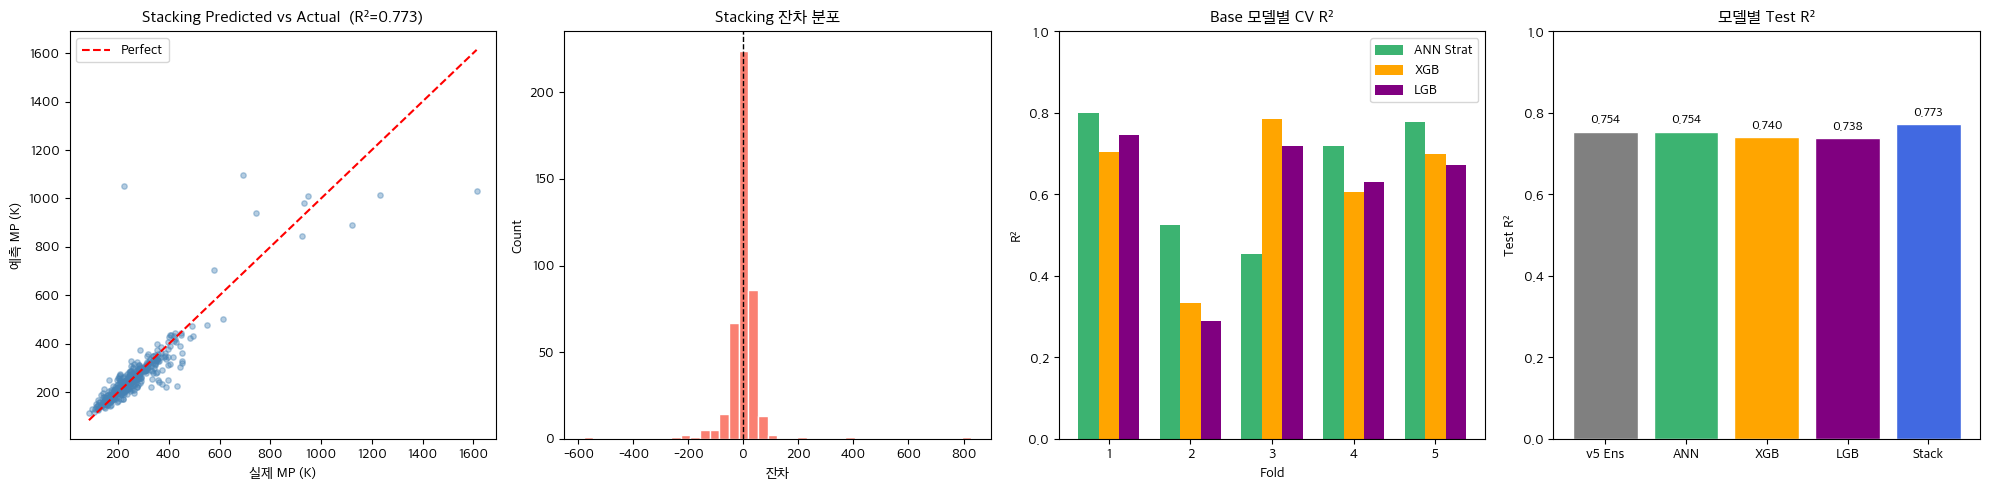

In [106]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.scatter(y_test, stack_pred, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), stack_pred.min()), max(y_test.max(), stack_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("실제 MP (K)"); ax.set_ylabel("예측 MP (K)")
ax.set_title(f"Stacking Predicted vs Actual  (R²={stack_r2:.3f})")
ax.legend()

ax = axes[1]
residuals = stack_pred - y_test
ax.hist(residuals, bins=40, color="salmon", edgecolor="white")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("잔차"); ax.set_ylabel("Count"); ax.set_title("Stacking 잔차 분포")

ax = axes[2]
x_pos = np.arange(1, 6); w = 0.25
ax.bar(x_pos - w, strat_r2, w, label="ANN Strat", color="mediumseagreen")
ax.bar(x_pos, xgb_r2_cv, w, label="XGB", color="orange")
ax.bar(x_pos + w, lgb_r2_cv, w, label="LGB", color="purple")
ax.set_xlabel("Fold"); ax.set_ylabel("R²"); ax.set_title("Base 모델별 CV R²")
ax.set_ylim(0, 1); ax.legend()

ax = axes[3]
labels = ["v5 Ens", "ANN", "XGB", "LGB", "Stack"]
vals   = [0.7536, ann_test_r2, xgb_test_r2, lgb_test_r2, stack_r2]
colors = ["gray", "mediumseagreen", "orange", "purple", "royalblue"]
ax.bar(labels, vals, color=colors, edgecolor="white")
ax.set_ylabel("Test R²"); ax.set_title("모델별 Test R²")
ax.set_ylim(0, 1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 14. 결과 요약 — v5 vs v9_optuna

In [107]:
summary = pd.DataFrame({
    "버전": [
        "v5_ann Strat CV", "v5_ann Scaffold CV",
        "v5_ann single-seed Test", "v5_ann 5-seed Ensemble Test",
        "v9_optuna ANN Test", "v9_optuna XGB Test", "v9_optuna LGB Test",
        "v9_optuna Stacking Meta Test"
    ],
    "R²": [
        "0.6543", "0.6458", "0.7895", "0.7536",
        f"{ann_test_r2:.4f}", f"{xgb_test_r2:.4f}", f"{lgb_test_r2:.4f}",
        f"{stack_r2:.4f}"
    ],
    "MAE / 편차": [
        "±0.140", "±0.065", "MAE 36.00", "MAE 32.00",
        f"MAE {ann_test_mae:.2f}", f"MAE {xgb_test_mae:.2f}", f"MAE {lgb_test_mae:.2f}",
        f"MAE {stack_mae:.2f}"
    ],
})
print("=== v5 vs v9_optuna 비교 ===")
print(f"노트북 전체 소요: {(time.time()-T0)/60:.1f}분")
print(f"Ridge 계수 해석 (ANN, XGB, LGB): {meta.coef_.round(3)}")
summary

=== v5 vs v9_optuna 비교 ===
노트북 전체 소요: 2.1분
Ridge 계수 해석 (ANN, XGB, LGB): [0.49  0.411 0.101]


,버전,R²,MAE / 편차
0,v5_ann Strat CV,0.6543,±0.140
1,v5_ann Scaffold CV,0.6458,±0.065
2,v5_ann single-seed Test,0.7895,MAE 36.00
3,v5_ann 5-seed Ensemble Test,0.7536,MAE 32.00
4,v9_optuna ANN Test,0.7536,MAE 32.00
5,v9_optuna XGB Test,0.7401,MAE 31.06
6,v9_optuna LGB Test,0.7381,MAE 32.11
7,v9_optuna Stacking Meta Test,0.7731,MAE 29.48
